<img src="recursos/logo_UTN.svg" align="right" width="150" /> 

#### Teoría de Circuitos II

# Tarea Semanal 2

Docentes: *LLAMEDO SORIA, Mariano* y *MOHAROS, David*

Autor: *MARCHESI, Matías Sebastián*


## Introducción

En esta tarea se busca obtener la transferencia pasa bajos utilizando la aproximación de máxima planicidad Butterworth de orden 6.

Se realizarán 3 etapas SOS. La primera un **SallenKey**, la segunda un **KHN** y la tercera un **MFB** a pedido del enunciado.

Se graficarán los polos , módulo y fase y luego se normalizará la red para obtener una ganancia de 10 dB en la banda de paso.

Finalmente, se realizarán las simulaciones correspondientes con LTSPice y en Python.

## Obtención de la transferencia general

Partiendo de la ecuación:

$$|K|^2 = \frac{|B|^2 - |A|^2}{|A|^2}$$

$$A(\omega^2) = 1$$
$$B(\omega^2) = b_0 . \omega_0 + b_2 . \omega^2 + b_4 . \omega^4 + ... + b_{2n} . \omega^{2n}$$

Con $b_0 = 1$

$$|K|^2 = \frac{|B|^2 - |A|^2}{|A|^2} = \frac{b_{2n} - \omega^{2n}}{1}$$



$$|T(j\omega)|^2 = \frac{1}{1 + |K|^2}$$
$$|T|^2 = \frac{1}{1 + b_{2n} . \omega^{2n}} = \frac{1}{1 + \epsilon^2 . \omega^{2n}}$$

Como estoy en el caso del Butterworth, se puede demostrar que $\epsilon^2 = 1$

$$|T|^2 = \frac{1}{1 + \omega^{2n}}$$

Reemplazando por $\large \omega=\frac{s}{j}$:

$$\large |T|^2 = \frac{1}{1 + \frac{s^{2n}}{j^{2n}}} = \frac{1}{1 + (-1)^n . s^{2n}}$$

Como tengo un $n=6$ fijado por la consigna, es par, entonces:

$$T|^2 = \frac{1}{1 + s^{12}} = T(s) . T(-s)$$

$$1+s^{12} = 0$$

$$s^{12} = -1$$

$$\large 1 . e^{j.12\theta} = 1 . e^{j.\pi(2k+1)}$$

$$\theta = \frac{(2k+1) \pi}{12}$$

$$\theta = \frac{k\pi}{6} + \frac{k\pi}{12}$$

$k=0,1,2,...,11$

Busco obtener solamente $T(s)$, o sea los polos del semiplano izquierdo.

Interpretando los **ángulos** llego a que los polos están distribuídos de la siguiente manera:

$$P_{1} = P_{1}* = \pm 15°$$
$$P_{2} = P_{2}* = \pm 45°$$
$$P_{3} = P_{3}* = \pm 75°$$

Dibujando los polos quedan de la siguiente manera:

<div style="text-align: center;">
  <img src="recursos/butterworth6_polos.png" width="350">
</div>

$$Q = \frac{1}{2.cos(\psi)}$$

Entonces obtengo los $Q$ de cada etapa:

$$Q_1 = 0.517$$
$$Q_2 = 0.707$$
$$Q_3 = 1.932$$

Ahora, voy a expresar los polos en formato cartesiano:

$$cos(15°) = \frac{\operatorname{Re}{P_1}}{1} = 0,965$$

$$sen(15°) = \frac{\operatorname{Im}{P_1}}{1} = 0,259$$

Solo lo hago para el primer caso, pero el resto es igual.

$$
\left\{
\begin{aligned}
p_1 &= -0.965 + j\,0.259 \\
p_1^* &= -0.965 - j\,0.259 \\
p_2 &= -0.707 + j\,0.707 \\
p_2^* &= -0.707 - j\,0.707 \\
p_3 &= -0.259 + j\,0.965 \\
p_3^* &= -0.259 - j\,0.965
\end{aligned}
\right.
$$

Ahora voy a pasar todo a formato S.O.S. (Second Order Section) como $\small (s - P_1) . (s - P_{1}*) = s^2 - 2\operatorname{Re}(P_{1}).s + |P_1|^2$.

Planteo esto como 3 S.O.S. en cascada:

$$T(s) = \frac{1}{s^2 - 2\operatorname{Re}(P_1) .s + |P_1|^2} . \frac{1}{s^2 - 2\operatorname{Re}(P_2) .s + |P_2|^2} . \frac{1}{s^2 - 2\operatorname{Re}(P_3) .s + |P_3|^2}$$

Ahora reemplazo por variables auxiliares más sencillas de manejar:

$$T(s) = \frac{1}{s^2 - a_1 .s + b_1} . \frac{1}{s^2 - a_2 .s + b_2} . \frac{1}{s^2 - a_3 .s + b_3}$$

Pongo los coeficientes $b_1=b_2=b_3=1$ porque tengo un **circulo de radio unitario**.

$a_1 = 2.\operatorname{Re}(P_1) = -1.93$

$a_2 = 2.\operatorname{Re}(P_2) = -1.414$

$a_3 = 2.\operatorname{Re}(P_3) = -0.518$

Finalmente, la $T(s)$ queda:

$$T(s) = \frac{1}{s^2 + 1.93 . s + 1} . \frac{1}{s^2 + 1.414 . s + 1} . \frac{1}{s^2 + 0.518 . s + 1}$$

Pudiendo separlas en $T_1(s), T_2(s), T_3(s)$

$$T(s) = T_1(s) . T_2(s) . T_3(s)$$

<div style="text-align:center;"">
    <div style="border: 2px solid #555; padding: 5px; border-radius: 8px; text-align: center; background-color: #f9f9f9; display: inline-block;">
        
  $$T_1(s) = \frac{1}{s^2 + 1.93 .s + 1}$$

  $$T_2(s) = \frac{1}{s^2 + 1.414 .s + 1}$$

  $$T_3(s) = \frac{1}{s^2 + 0.518 .s + 1}$$
    </div>
</div>


### Módulo, fase y Polos

Para $\omega = 0$, el aporte de fase de cada par de polos conjugados se cancela, resultando fase total nula. Y para $\omega \to \infty$, cada polo aporta $-\frac{\pi}{2}$ rad, por lo que:

$$
\large \phi_{total} = -6 \cdot \frac{\pi}{2} = -3\pi \, \text{rad}
$$

Por lo tanto, la fase presenta un comportamiento decreciente con un desenvolvimiento total de $3\pi$ rad.

Expresándolo gráficamente queda de la siguiente manera:

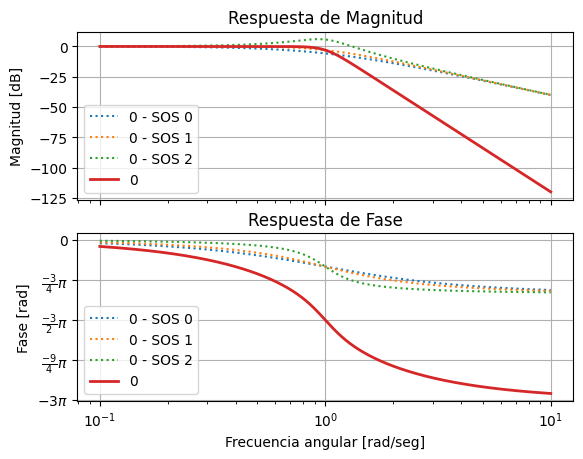

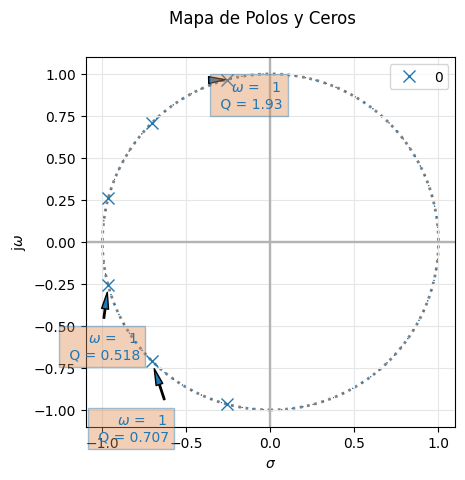

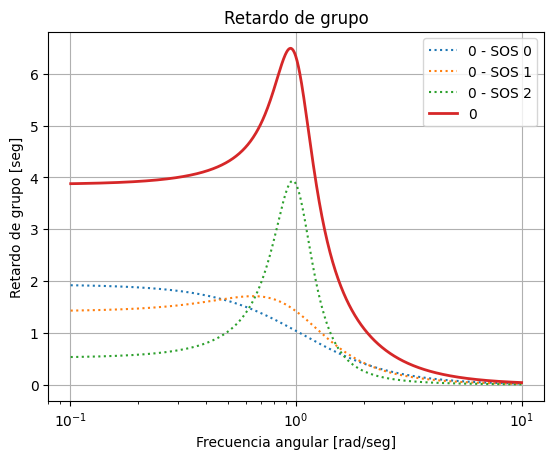

In [8]:
import scipy.signal as sig
from pytc2.sistemas_lineales import tf2sos_analog, analyze_sys 

# Filtro Butterworth de orden 6 normalizado
z, p, k = sig.buttap(6)

num, den = sig.zpk2tf(z, p, k)

# Conversión a secciones de segundo orden
this_sos = tf2sos_analog(num, den)

# Análisis (módulo y fase)
_ = analyze_sys(this_sos)

Ahora procedo a analizar etapa por etapa cada circuito. Siendo la $T_1(s)$ correspondiente a un **Sallen Key**, la $T_2(s)$ correspondiente a un **KHN** y la $T_3(s)$ correspondiente a un **MFB**.

## Sallen Key

### Desarrollo de la transferencia

Parto del siguiente circuito y le nombro los nodos:

<div style="text-align: center;">
  <img src="recursos/sallenkey_sinvalores.png" width="400">
</div>

Resuelvo por el método de nodos:
$${\color{red}(1)} V_A.(G_1 + G_2 + s.C_2) - V_1 . G_1 - V_B . G_2 - V_O . s . C_2 = 0$$

$${\color{red}(2)} V_B.(G_2 + s.C_1) - V_A . G_2 = 0$$

$${\color{red}(3)} V_B.(G_3 + G_4) - V_O . G_4 = 0$$

$$V_O = K_1 . V_B\,\ con \ K_1 = 1 + \frac{R_4}{R_3}$$

Comienzo por despejar la ecuación (2):
$$V_B = \frac{G_2}{G_2 + s . C_1}.V_A$$

Ahora opero en (1):
$$V_A.(G_1 + G_2 + s.C_2) - V_1.G_1 - V_B . G_2 - V_O.s.C_2 = 0$$

$$V_A.(G_1 + G_2 + s.C_2) - V_1.G_1 - V_B . (G_2 + k.s.C_2 ) = 0$$

Reemplazando (2) en (1):
$$V_A.(G_1 + G_2 + s.C_2) - V_1.G_1 - \frac{G_2}{G_2 + s . C_1}.V_A . G_2 - V_O.s.C_2 = 0$$

Reemplazando $V_A = \frac{V_O}{K_1} . \frac{G_2 + s.C_1}{G_2}$ y operando se consigue una transferencia $T_1(s)$:

$$T_1(s)=\frac{V_O}{V_I} = K_1 . \frac{G_1.G_2}{s^2.C_1.C_2 + s.(C_1.G_1 + C_1.G_2+C_2.G_2-C_2.G_2.K_1) + G_1.G_2}$$

$$T_1(s)=\frac{V_O}{V_I} = K_1 . \frac{\frac{1}{R_1.R_2.C_1.C_2}}{s^2 + s.(\frac{C_1.G_1 + C_2.G_2 + C_2.G_2.(1-K_1)}{C_1.C_2}) + \frac{G_1.G_2}{C_1.C_2}}$$

Considerando $C_1=C_2=C$ para simplificar la ecuación obtengo:
<div style="text-align:center;"">
    <div style="border: 2px solid #555; padding: 5px; border-radius: 8px; text-align: center; background-color: #f9f9f9; display: inline-block;">
  $$T_1(s)=K_1.\frac{\frac{G_1.G_2}{C^2}}{s^2 + s.(\frac{G_1+G_2.(2-K_1)}{C}) + \frac{G_1.G_2}{C^2}}$$
    </div>
</div>

Llevándolo a la forma genérica de un pasabajos:
$$T_1(s) = K_1 . \frac{\omega_0^2}{s^2 + s.\frac{\omega_0}{Q_1} + \omega_0^2}$$

* $\large \omega_0^2 = \frac{G_1.G_2}{C^2} \rightarrow \omega_0 = \frac{\sqrt{G_1.G_2}}{C}$

* $\large \frac{\omega_0}{Q_1} = \frac{G_1+G_2.(2-K_1)}{C}$

$$\frac{1}{Q_1} . \frac{\sqrt{G_1.G_2}}{C} = \frac{G_1 + G_2.(2-K_1)}{C}$$

$$\frac{1}{Q_1} = \frac{G_1 + G_2.(2-K_1)}{\sqrt{G_1.G_2}}$$

Tomando $G_1=G_2=G$

$$Q_1 = \frac{1}{3-K_1}$$

$$K_1 = 3 - \frac{1}{Q_1}=1 + \frac{R_4}{R_3}$$

Con $Q_1=0.517$ por lo que se calculó anteriormente obtengo $K_1$:

<div style="text-align:center;"">
    <div style="border: 2px solid #555; padding: 5px; border-radius: 8px; text-align: center; background-color: #f9f9f9; display: inline-block;">
  $$K_1 = 1.065764$$
    </div>
</div>

**Nota**: Se deja expresado con tantos decimales para mayor precisión

$$\frac{R_4}{R_3} = 0.065764$$

### Normalización
Tomaré como norma de frecuencia $\Omega_\omega = \omega_0 = 1 = \frac{1}{R.C}$

Por lo que $R=\frac{1}{C}$.

Tomo como norma de impedancia $\Omega_Z = R = 1\Omega$

Entonces $C=1F$

Adopto $R_3=1\Omega$ conforme a la $\Omega_Z$

Ahora puedo despejar $R_4$ según la ecuación que había obtenido antes.

Llegando a $R_4=0.065764\Omega$

### Simulación

Se colocan los valores de los componentes en el circuito:
<div style="text-align: center;">
  <img src="recursos/sallenkey_normalizado.png" width="400">
</div>

Simulo el circuito con las siguiente directivas de LTSpice `.ac dec 10000 1u 1K` y colocando un generador como entrada de $V_I$ y obtengo:

#### Módulo
<div style="text-align: center;">
  <img src="recursos/sallenkey_modulo.png" width="500">
</div>

#### Fase
<div style="text-align: center;">
  <img src="recursos/sallenkey_fase.png" width="500">
</div>

Comprobando que es un filtro pasabajos. La ganancia en la banda la obtengo usando los cursores del LTSpice comprobando lo calculado anteriormente:

<div style="text-align: center;">
  <img src="recursos/sallenkey_ganancia.png" width="500">
</div>

Teniendo una ganancia de $1.0656772$ en la banda de paso, cosa que es muy cercana a los $1.065764$ obtenidos analíticamente.

## Ganancia en la banda de paso

Un requisito que pide el ejercicio es tener una ganancia en la banda de paso de $10dB$.
Recién ahora menciono esto ya que en el caso del Sallen Key el $K_1$, que es el que da la ganancia, está fijado por el $Q_1$ que obtuve al momento de realizar los cálculos al principio del ejercicio. Por lo cual, no puedo modificarlo.

Lo que si puedo modificar es la ganancia de las próximas dos etapas que realizaré.
Es por eso que primero voy a pasar la ganancia total a veces.

$$K_T = 10^{\frac{10dB}{20}} = 3.16$$

Siendo a su vez $K_T$ el producto de la ganancia de cada etapa.

$$K_T = K_1 . K_2 . K_3$$

Con $K_1 = 1.065764$:
$$\frac{K_T}{K_1} = K_2 . K_3 = 2.967146$$

Conociendo como serán las próximas etapas (MFB y KHN), sé que será más simple poder fijar la ganancia de $K_3$ por la mayor simpleza del circuito comparado con el KHN.

Por lo que, tomaré como $K_3$ la ganancia que necesito para llegar a esos $10dB$ y dejaré que $K_2$ sea unitaria.


<div style="text-align:center;"">
    <div style="border: 2px solid #555; padding: 5px; border-radius: 8px; text-align: center; background-color: #f9f9f9; display: inline-block;">
    $$K_2 = 1$$
    $$K_3 = 2.967146$$
    </div>
</div>

A su vez, comienzo por resolver el MFB primero porque es más sencillo.

## Multiple Feedback (MFB)

### Desarrollo de la transferencia

Parto del siguiente circuito y le nombro los nodos acordemente:
<div style="text-align: center;">
  <img src="recursos/mfb_sinvalores.png" width="400">
</div>

Planteo las ecuaciones el método de resolución de circuitos por nodos:

$${\color{red}(1)} V_A.(G_1 + G_2 + G_3 + s.C_1) - V_1 . G_3 - V_B . G_2 - V_O . G_1 = 0$$

$${\color{red}(2)} V_B.(G_2 + s.C_2) - V_A . G_2  - V_O . s . C_2= 0$$

$${\color{red}(3)} V_B = 0$$

Por tener $V^+$ conectada a masa, se toma tierra virtual en $V^- = V_B = 0$.

Reescribo las ecuaciones:
$${\color{red}(1)} V_A.(G_1 + G_2 + G_3 + s.C_1) - V_1 . G_3 - V_O . G_1 = 0$$

$${\color{red}(3)} V_A = - V_O . \frac{s.C_2}{G_2}$$

Poniendo la ecuación (3) en (1):
$$-V_O.\frac{s.C_2}{G_2}.[G_1+G_2+G_3+s.C_1] - V_I.G_3 = V_O . G_1$$

Acomodando la ecuación y llevándolo a la expresión $T_3(s) = \frac{V_O}{V_I}$

$$\frac{V_O}{V_I}=T_3(s)=-\frac{G_3}{s^2.\frac{C_1.C_2}{G_2} + s(\frac{G_1.C_2}{G_2} + \frac{G_3.C_2}{G_2} + C_2) + G_1}$$

Multiplico y divido por $\frac{G_2}{C_1.C_2}$ para llegar a la expresión final:
<div style="text-align:center;"">
    <div style="border: 2px solid #555; padding: 5px; border-radius: 8px; text-align: center; background-color: #f9f9f9; display: inline-block;">
$$T_3(s) = -\frac{\frac{G_2.G_3}{C_1.C_2}}{s^2 + s(\frac{G_1}{C_1} + \frac{G_2}{C_1} + \frac{G_3}{C_1}) + \frac{G_1.G_2}{C_1.C_2}}$$
    </div>
</div>

Llevándolo a la forma genérica de un pasabajos:
$$T_3(s) = K_3 . \frac{\omega_0^2}{s^2 + s.\frac{\omega_0}{Q_3} + \omega_0^2}$$

Reemplazo por los datos que tengo $K_3 = 2.967146\ , \omega_0^2 = 1\ y \ Q_3 = 1.932$.

$$T_3(s) = 2.967146 . \frac{1}{s^2 + s.\frac{1}{1.932} + 1}$$

$$
\begin{align*}
\bullet \quad \omega_0^2 &= \frac{G_1 G_2}{C_1 C_2} = 1 \\
\bullet \quad \frac{1}{Q_3} &= \frac{G_1}{C_1} + \frac{G_2}{C_1} + \frac{G_3}{C_1} = 0.517 \\
\bullet \quad K_3 &= - \frac{G_2 G_3}{G_1 G_2} = -\frac{G_3}{G_1} = -2.967146
\end{align*}
$$

Puedo despejar que $G_3 = G_1.2.967146$.

### Normalización

Impongo $\Omega_\omega=\omega_0 = 1$. Y tomo como $\Omega_Z = G_1 = 1$.

A su vez, necesito sacar un grado de libertad, por lo tanto fijo $G_2 = 1$.

Con eso puedo despejar $G_3 = 2.967146$.
También puedo despejar $C_1$
$$0.517 = \frac{1 + 1 + 2.967146}{C_1} \Rightarrow C_1 \approx 9.5965 F$$

Y con esos valores y la definición de $\Omega_0^2$ hallo el valor de $C_2$ que me falta:

$$\frac{G_1.G_2}{C_1.C_2} = 1$$

$$\frac{1}{9.5965.C_2} = 1 \Rightarrow C_2 \approx 0.1042 F$$ 

Resumiendo los valores que me quedaron son:

<div style="text-align:center;"">
    <div style="border: 2px solid #555; padding: 5px; border-radius: 8px; text-align: center; background-color: #f9f9f9; display: inline-block;">
$$R_1 = 1\Omega$$
$$R_2 = 1\Omega$$
$$R_3 = \frac{1}{G_3} = 0.337\Omega$$
$$C_1 = 9.5965 F$$
$$C_2 = 0.1042 F$$
    </div>
</div>

Con estos valores ya puedo simular el circuito en LTSpice.

### Simulación

Se colocan los valores de los componentes en el circuito:

<div style="text-align: center;">
  <img src="recursos/mfb_normalizado.png" width="400">
</div>

Simulo el circuito con las siguiente directivas de LTSpice `.ac dec 10000 1u 1K` y colocando un generador como entrada de $V_I$ y obtengo:
#### Módulo

<div style="text-align: center;">
  <img src="recursos/mfb_modulo.png" width="500">
</div>

#### Fase
<div style="text-align: center;">
  <img src="recursos/mfb_fase.png" width="500">
</div>

Comprobando que es un filtro pasabajos. La ganancia en la banda la obtengo usando los cursores del LTSpice comprobando lo calculado anteriormente:

<div style="text-align: center;">
  <img src="recursos/mfb_ganancia.png" width="500">
</div>

Teniendo una ganancia de $2.9671244$ en la banda de paso, cosa que es muy cercana a los $2.967146$ impuestos anteriormente.

## Kerwin–Huelsman–Newcomb (KHN)

### Desarrollo de la transferencia

Para esta última etapa el circuito es el siguiente:
<div style="text-align: center;">
  <img src="recursos/khn_sinvalores.png" width="400">
</div>

Para este caso resulta más sencillo hacer el análisis circuital mediante el **método de superposición** ya que este filtro genera 3 salidas.
$$
\begin{align*}
\bullet \quad V_1 = V_h \ (Pasa Altos) \\
\bullet \quad V_2 = V_b \ (Pasa Banda) \\
\bullet \quad V_3 = V_l \ (Pasa Bajos)
\end{align*}
$$

Asignando los nombres a los nodos se obtiene:
<div style="text-align: center;">
  <img src="recursos/khn_nodos.png" width="400">
</div>

#### Análisis para $V_1$

$$
\begin{aligned}
V_1 &= \left. V_1 \right|_{V_2 = V_3 = \varnothing}
      + \left. V_1 \right|_{V_2 = V_3 = \varnothing}
      + \left. V_1 \right|_{V_6 = V_2 = \varnothing} \\
    &\color {red}\qquad \underbrace{\hspace{1.5cm}}_{(1)}
    \qquad \underbrace{\hspace{1.5cm}}_{(2)}
    \qquad \underbrace{\hspace{1.5cm}}_{(3)}
\end{aligned}
$$

${\color{red}(1)}$:
Busco hallar $V_1(V_i)$
Pasivando $V_2$ y $V_3$ por $R_6$ y $R_7$ no circula corriente. Por otro lado, $R_4$ no interviene en la transferencia, entonces queda de la siguiente manera la ecuación:

$${\color{red}(4)}\ V_1 = - V_i . \frac{R_3}{R_1}$$

${\color{red}(3)}$:
Busco hallar $V_1(V_3)$
Pasivando $V_i$ y $V_2$ el análisis es el mismo que con el caso anterior, quedando de la siguiente manera la ecuación: 
$${\color{red}(5)}\ V_1 = - V_3 . \frac{R_3}{R_2}$$

${\color{red}(2)}$:
Busco hallar $V_1(V_2)$
Pasivando $V_i$ y $V_3$ por $R_1$, $R_2$ y $R_3$ no circula corriente, quedando de la siguiente manera la ecuación: 
$${\color{red}(6)}\ V_1 = V_2 . \frac{R_7}{R_6 + R_7}$$

Quedando $V_1$ finalmente como la sumatoria de ${\color{red}(4)}$, ${\color{red}(5)}$ y ${\color{red}(6)}$:  

$${\color{red}(7)}\ V_1 = -V_i . \frac{R_3}{R_1} + V_2 . \frac{R_7}{R_6 + R_7} - V_3 . \frac{R_3}{R_2}$$

#### Análisis para $V_2$

Para este caso, lo voy a tratar como un bloque aislado donde mi tensión de entrada es $V_1$.

$${\color{red}(8)}\ V_2 = -V_1 . \frac{1}{s.C_1.R_4}$$

#### Análisis para $V_3$

En este caso también lo trato como un bloque aislado donde la tensión de entrada es $V_2$.

$${\color{red}(9)}\ V_3 = - V_2 . \frac{1}{s.C_2.R_5}$$

#### Obtención de $\large \frac{V_3}{V_i}$

Reemplazo ${\color{red}(8)}$ en ${\color{red}(9)}$:
$$V_3 = \cancel{-}V_1.\frac{1}{s.C_1.R_4}.(\ \cancel{-}\frac{1}{s.C_2.R_5})$$

$$V_3 = V_1 . (\frac{1}{s^2.C_1.C_2.R_4.R_5})$$

$$V_1 = V_3 . (s^2.C_1.C_2.R_4.R_5)$$

Llevo esto a ${\color{red} (7)}$:

$$V_3 . (s^2.C_1.C_2.R_4.R_5) = -V_i . \frac{R_3}{R_1} - V_3 . \frac{s^\cancel{2}.\cancel{C_1}.C_2.\cancel{R_4}.R_5}{\cancel{s}.\cancel{C_1}.\cancel{R_4}}.\frac{R_7}{R_6 + R_7} - V_3 .\frac{R_3}{R_2}$$

Ahora multiplico y divido por $C_1.C_2.R_4.R_5$:

$$V_3.(s^2 + s.\frac{1}{C_1.R_4}.\frac{R_7}{R_6 + R_7} + \frac{R_3}{C_1.C_2.R_2.R_4.R_5}) = - V_i . \frac{R_3}{C_1.C_2.R_1.R_4.R_5}$$

Siendo $\large T_2(s) = \frac{V_3}{V_i}$:
<div style="text-align:center;"">
    <div style="border: 2px solid #555; padding: 5px; border-radius: 8px; text-align: center; background-color: #f9f9f9; display: inline-block;">
$$\large T_2(s) = \frac{\frac{R_3}{C_1.C_2.R_1.R_4.R_5}}{s^2 + s.\frac{R_7}{C_1.R_4.(R_6 + R_7)} + \frac{R_3}{C_1.C_2.R_2.R_4.R_5}}$$
    </div>
</div>

Llevándolo a la forma genérica de un pasabajos:
$$T_2(s) = K_2 . \frac{\omega_0^2}{s^2 + s.\frac{\omega_0}{Q_2} + \omega_0^2}$$

$K_2$ absorbe el signo negativo.

Reemplazando por los datos que tengo $K_2 = -1\ , \omega_0^2 = 1\ y \ Q_2 = 0.707$.

$$\large T_2(s) = -\frac{1}{s^2 + s.\frac{1}{0.707} + 1}$$

$$
\begin{align*}
\bullet \quad \omega_0^2 &= \frac{R_3}{C_1.C_2.R_2.R_4.R_5} = 1 \\
\bullet \quad \frac{1}{Q_2} &= \frac{R_7}{C_1.R_4.(R_6 + R_7)} = \frac{1}{0.707} \\
\bullet \quad K_2 &= - \frac{R_2}{R_1} = -1
\end{align*}
$$

### Normalización

Impongo $\Omega_\omega=\omega_0 = 1$. Y tomo como $\Omega_Z = R_5 = 1 \Omega$.
A su vez, impongo $C_1=C_2=1 F$

$$K = -1 = -\frac{R_2}{R_1} \Rightarrow R_1 = R_2$$

$$\frac{1}{0.707} = \frac{R_7}{R_4.(R_6 + R_7)}$$
Impongo $R_7 = 1 \Omega$.

$$\frac{1}{0.707} = \frac{1}{R_4.(R_6 + 1)}$$

$$R_4.R_6 + R_4 = 0.707$$
Para que se cumpla esta igualdad tomo $R_6 = 1 \Omega$.

$$2.R_4 = 0.707$$
$$R_4 = 0.3535 \Omega$$

A su vez, impongo $R_1=R_2=1 \Omega$ para cumplir la igualdad.

Por último, desde la fórmula de $\omega_0^2$ despejo $R_3$ y $R_5$:
$$\omega_0^2 = \frac{R_3}{R_5} = 1$$
Impongo, para finalizar $R_3=R_5=1 \Omega$

Resumiendo los valores que me quedaron son:

<div style="text-align:center;"">
    <div style="border: 2px solid #555; padding: 5px; border-radius: 8px; text-align: center; background-color: #f9f9f9; display: inline-block;">
$$R_1 = 1\Omega$$
$$R_2 = 1\Omega$$
$$R_3 = 1\Omega$$
$$R_4 = 0.3535\Omega$$
$$R_5 = 1\Omega$$
$$R_6 = 1\Omega$$
$$R_7 = 1\Omega$$
$$C_1 = 1 F$$
$$C_2 = 1 F$$
    </div>
</div>

Con esto ya puedo simularlo en LTSpice.

### Simulación

Se colocan los valores de los componentes en el circuito:

<div style="text-align: center;">
  <img src="recursos/khn_normalizado.png" width="400">
</div>

Simulo el circuito con las siguiente directivas de LTSpice `.ac dec 10000 1u 1K` y colocando un generador como entrada de $V_I$ y obtengo:
#### Módulo

<div style="text-align: center;">
  <img src="recursos/khn_modulo.png" width="500">
</div>

#### Fase
<div style="text-align: center;">
  <img src="recursos/khn_fase.png" width="500">
</div>

Comprobando que es un filtro pasabajos. La ganancia en la banda la obtengo usando los cursores del LTSpice comprobando lo calculado anteriormente:

<div style="text-align: center;">
  <img src="recursos/khn_ganancia.png" width="500">
</div>

Teniendo una ganancia de $999.96998m$ en la banda de paso, cosa que es muy cercana a la ganancia unitaria planteada analíticamente.

## Unificando las tres etapas

Ahora con las tres etapas calculadas y simuladas por separado solo queda unificarlos y simularlas.

<div style="text-align: center;">
  <img src="recursos/butterworth6_todojunto.png" width="800">
</div>

Es importante aclarar que entre cada etapa se agrega un seguidor que actua como una etapa de buffer que simplemente separa una etapa de otra.

El seguidor se ve de la siguiente manera:

<div style="text-align: center;">
  <img src="recursos/seguidor.png" width="350">
</div>

Por último, simulando esto en LTSpice con la directiva `.ac dec 10000 1u 1K` y colocando un generador como entrada de $V_i$ y obtengo:

### Módulo

<div style="text-align: center;">
  <img src="recursos/final_modulo.png" width="500">
</div>

### Fase
<div style="text-align: center;">
  <img src="recursos/final_fase.png" width="500">
</div>

Comprobando que es un filtro pasabajos. La ganancia en la banda la obtengo usando los cursores del LTSpice comprobando lo calculado anteriormente:

<div style="text-align: center;">
  <img src="recursos/final_ganancia.png" width="500">
</div>

Teniendo una ganancia de $9.9989927dB$ en la banda de paso, cosa que es muy cercana a los $10dB$ pedidos por la consigna.

## Conclusiones

Por último, analizando la fase simulada contra la fase obtenida en python se ve que se tiene un resultado similar.
Partiendo de los 0° hasta los 540° como también se vio en 


Por último, se realiza la comparación entre la respuesta teórica del filtro, obtenida mediante simulación en Python, y la respuesta del circuito implementado en LTSpice luego de todos los cálculos etapa a etapa.

Se observa que ambas respuestas presentan un muy buen acuerdo tanto en módulo como en fase. En particular, la aproximación Butterworth de orden 6 cumple con el comportamiento esperado, sin ripple. La frecuencia de corte se mantiene consistente entre ambos modelos, verificando que la normalización fue correctamente elegida.

Las diferencias entre las curvas simuladas con LTSpice contra las de Python las puedo atribuir principalmente porque se multiplican 3 etapas, que por más que esté la presencia de los buffer, hay variaciones debido a redondeos y otros factores que el LTSpice si considera. De todos modos, no son diferencias considerables, ya que el filtro se sigue comportando como es esperable pese a eso.

Básicamente, la implementación en LTSpice valida lo desarrollado analíticamente y lo simulado en Python. Cumpliendo con la ganancia deseada en la banda de paso.

## Resolución para Butterworth con $n=7$

Comienzo por simular en Python el butterworth con $n=7$.

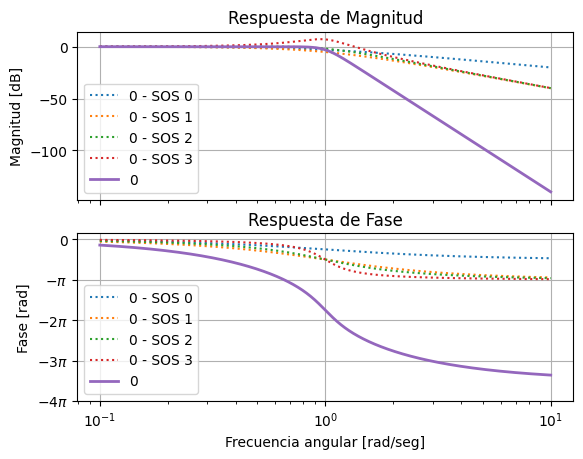

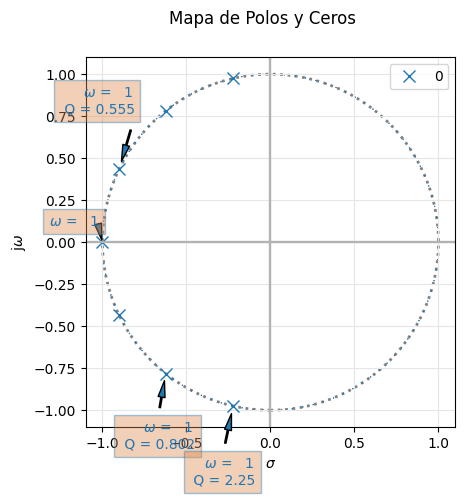

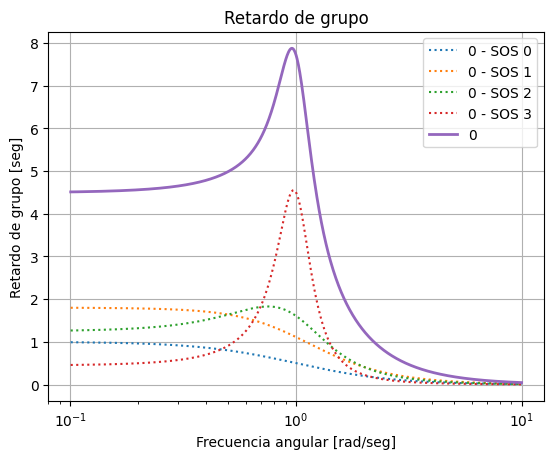

In [9]:
import scipy.signal as sig
from pytc2.sistemas_lineales import tf2sos_analog, analyze_sys 

# Filtro Butterworth de orden 7 normalizado
z, p, k = sig.buttap(7)

num, den = sig.zpk2tf(z, p, k)

# Conversión a secciones de segundo orden
this_sos = tf2sos_analog(num, den)

# Análisis (módulo y fase)
_ = analyze_sys(this_sos)

Comparándolo con lo obtenido anteriormente para el butterworth de $n=6$.

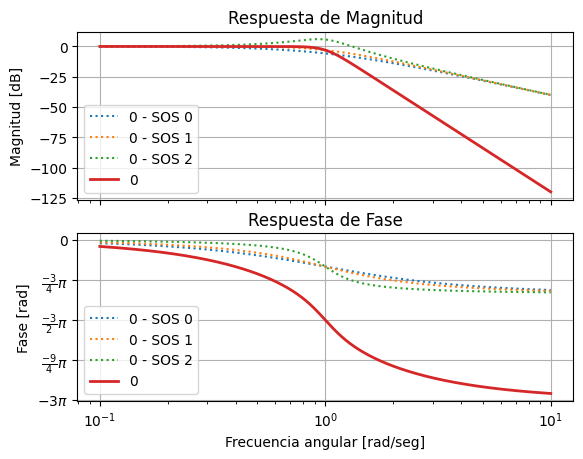

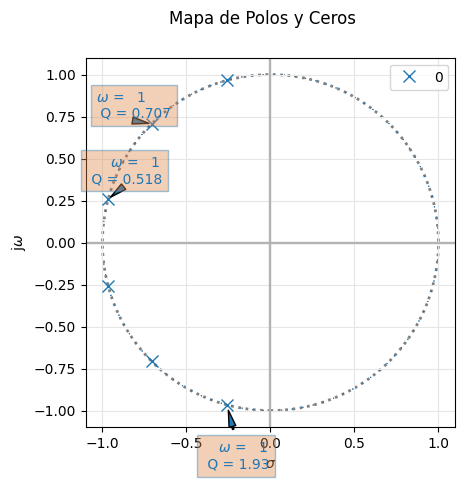

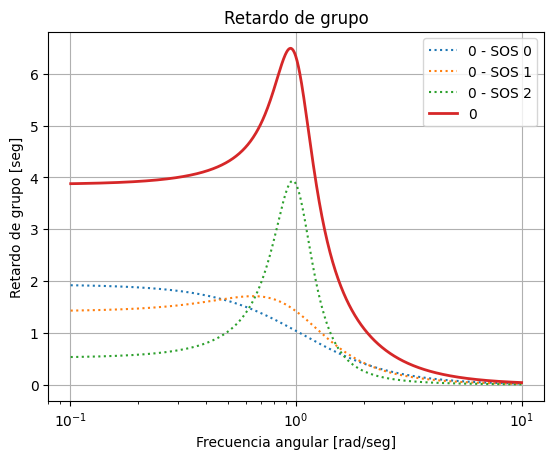

In [10]:
import scipy.signal as sig
from pytc2.sistemas_lineales import tf2sos_analog, analyze_sys 

# Filtro Butterworth de orden 6 normalizado
z, p, k = sig.buttap(6)

num, den = sig.zpk2tf(z, p, k)

# Conversión a secciones de segundo orden
this_sos = tf2sos_analog(num, den)

# Análisis (módulo y fase)
_ = analyze_sys(this_sos)

A simple vista se ve que hay algunas diferencias.

* El orden 6 presenta 3 pares de polos complejos conjugados, cosa que en el orden 7 aparece, y además aparece otro polo en el mismo semiplano sobre el eje, o sea de ángulo 0°.
* Al tener un polo extra, se puede ver en la respuesta de fase que decrecerá con mayor pendiente, $20\frac{dB}{dec}$ más rápido.

Ahora sabiendo que los $Q$ cambiaron se puede ver que no puedo reutilizar los mismos componentes que utilicé para el análisis de $n=6$. Pero se podrían recalcular.

Por último agregaría una última etapa separada con un seguidor que conste de un $RC$.

Como estoy sobre una circunferencia de radio unitario $\omega_0$ es 1.

$$R.C = 1$$

Y puedo normalizarlo directamente a:
$$R=1\Omega$$
$$C=1 F$$

### Recalculando los $Q$
Vuelvo a la ecuación del principio para calcular los $Q$.

$$\large |T|^2 = \frac{1}{1 + \frac{s^{2n}}{j^{2n}}} = \frac{1}{1 + (-1)^n . s^{2n}}$$

Como tengo un $n=7$:

$$1 - s^{14} = 0 \Rightarrow s^{14} = 1$$

$$\large 1.e^{j14.\theta} = 1.e^{j.2\pi.K}\ con\ k=0,1,2,...,13$$

$$\theta = \frac{\pi.K}{7}$$

En este caso, solo busco los polos del semiplano izquierdo.

$$P_1 = P_1* = \pm \frac{\pi}{7}$$

$$P_2 = P_2* = \pm \frac{2.\pi}{7}$$

$$P_3 = P_3* = \pm \frac{3.\pi}{7}$$

Y por último aparece el polo real:

$$P_4 = -1$$

Ahora voy a expresar los polos en formato cartesiano:
$$cos(\frac{\pi}{7}) = \frac{\operatorname{Re}{P_1}}{1}$$

$$sen(\frac{\pi}{7}) = \frac{\operatorname{Im}{P_1}}{1}$$
Solo lo hago para el primer caso, pero el resto es igual.

$$
\left\{
\begin{aligned}
p_1 &= -0.900 + j\,0.434 \\
p_1^* &= -0.900 - j\,0.434 \\
p_2 &= -0.623 + j\,0.782 \\
p_2^* &= -0.623 - j\,0.782 \\
p_3 &= -0.223 + j\,0.975 \\
p_3^* &= -0.223 - j\,0.975 \\
p_4 &= -1 
\end{aligned}
\right.
$$

Calculo los $Q$.

$$Q = \frac{1}{2.cos(\psi)}\ con \ \psi=\frac{\pi}{7},\ \frac{2\pi}{7}, \ \frac{3\pi}{7}$$

$$
\left\{
\begin{aligned}
Q_1 &= \frac{1}{2.cos(\frac{\pi}{7})} = 0.554 \\
Q_2 &= \frac{1}{2.cos(\frac{2\pi}{7})} = 0.802\\
Q_3 &= \frac{1}{2.cos(\frac{3\pi}{7})} = 2.247\\
\end{aligned}
\right.
$$

Y planteo la expresión $T(s)$:

$$T(s) = \frac{1}{s^2 + \frac{1}{0.554}.s + 1} . \frac{1}{s^2 + \frac{1}{0.802}.s + 1} . \frac{1}{s^2 + \frac{1}{2.24}.s + 1} . \frac{1}{s+1}$$

Pudiendo separarlas en $T_1(s), T_2(s), T_3(s), T_4(s)$

$$T(s) = T_1(s) . T_2(s) . T_3(s) . T_4(s)$$

<div style="text-align:center;"> <div style="border: 2px solid #555; padding: 5px; border-radius: 8px; text-align: center; background-color: #f9f9f9; display: inline-block;">
$$T_1(s) = \frac{1}{s^2 + \frac{1}{0.554}.s + 1}$$
$$T_2(s) = \frac{1}{s^2 + \frac{1}{0.802}.s + 1}$$
$$T_3(s) = \frac{1}{s^2 + \frac{1}{2.24}.s + 1}$$
$$T_4(s) = \frac{1}{s+1}$$

</div>

</div>


Por último, dejo adjunto un diagrama ilustrativo de como quedaría el circuito:

<div style="text-align: center;">
  <img src="recursos/butterworth7_diag_final.png" width="500">
</div>